循环神经网络的从零开始实现

先读取数据集

In [1]:
%matplotlib inline
import math
import torch
from torch import nn
from torch.nn import functional as F

In [2]:
import torch
import random
import re
import requests
from collections import Counter

# 读取数据
url = "http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt"
file_path = "timemachine.txt"

response = requests.get(url)
with open(file_path, "wb") as f:
    f.write(response.content)

def read_time_machine():
    with open(file_path, 'r') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

lines = read_time_machine()

# 字符级tokenize
tokens = [list(line) for line in lines]
corpus = [char for line in tokens for char in line]

# 构建词表
class Vocab:
    def __init__(self, tokens):
        counter = Counter(tokens)
        self.idx_to_token = list(counter.keys())
        self.token_to_idx = {token: i for i, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, token):
        return self.token_to_idx[token]

vocab = Vocab(corpus)

# 转成索引
corpus = [vocab[token] for token in corpus]

# 构造数据迭代器（顺序分区版）
def load_data_time_machine(batch_size, num_steps):
    corpus_tensor = torch.tensor(corpus, dtype=torch.long)
    num_tokens = (len(corpus_tensor) // batch_size) * batch_size
    corpus_tensor = corpus_tensor[:num_tokens]

    corpus_tensor = corpus_tensor.reshape(batch_size, -1)

    num_batches = (corpus_tensor.shape[1] - 1) // num_steps

    def data_iter():
        for i in range(0, num_batches * num_steps, num_steps):
            X = corpus_tensor[:, i:i+num_steps]
            Y = corpus_tensor[:, i+1:i+num_steps+1]
            yield X, Y

    return data_iter(), vocab



batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

# 测试一下
for X, Y in train_iter:
    print(X.shape, Y.shape)
    break

torch.Size([32, 35]) torch.Size([32, 35])


独热编码

在train_iter中，每个词元都表示为一个数字索引， 将这些索引直接输入神经网络可能会使学习变得困难。 我们通常将每个词元表示为更具表现力的特征向量。 最简单的表示称为独热编码（one-hot encoding）。

将每个索引映射为相互不同的单位向量

 索引为 0 和 2 的独热向量如下所示：

In [3]:
F.one_hot(torch.tensor([0, 2]), len(vocab))

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0]])

每次采样的小批量数据形状是二维张量：批量大小，时间步数。

one_hot函数将这样一个小批量数据转换成三维张量， 张量的最后一个维度等于词表大小（len(vocab)，转换输入的维度，以便获得形状为 （时间步数，批量大小，词表大小）的输出。

In [4]:
X = torch.arange(10).reshape((2, 5))
F.one_hot(X.T, 28).shape

torch.Size([5, 2, 28])

初始化模型参数

初始化循环神经网络模型的模型参数。

隐藏单元数num_hiddens是一个可调的超参数。，输入输出来自相同列表，因此有相同的维度。

In [5]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01

    # 隐藏层参数
    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

循环神经网络模型

需要一个init_rnn_state函数在初始化时返回隐状态

In [6]:
def init_rnn_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

下面的rnn函数定义了如何在一个时间步内计算隐状态和输出。

In [7]:
def rnn(inputs, state, params):
    # inputs的形状：(时间步数量，批量大小，词表大小)
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    # X的形状：(批量大小，词表大小)
    for X in inputs:
        H = torch.tanh(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h)
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

定义了所有需要的函数之后，接下来我们创建一个类来包装这些函数， 并存储从零开始实现的循环神经网络模型的参数。

In [8]:
class RNNModelScratch:
    """从零开始实现的循环神经网络模型"""
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params, init_state, forward_fn):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state, forward_fn

    def __call__(self, X, state):
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)

检查输出是否具有正确的形状

In [9]:
import torch

# 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_hiddens = 512

net = RNNModelScratch(
    len(vocab),
    num_hiddens,
    device,
    get_params,
    init_rnn_state,
    rnn
)

# 初始化状态
state = net.begin_state(batch_size=X.shape[0], device=device)

# 前向传播
Y, new_state = net(X.to(device), state)

print(Y.shape, len(new_state), new_state[0].shape)

torch.Size([10, 27]) 1 torch.Size([2, 512])


输出形状是（时间步数 × 批量大小，词表大小）， 而隐状态形状保持不变，即（批量大小，隐藏单元数）。

预测

定义预测函数来生成prefix之后的新字符，prefix是一个用户提供的包含多个字符的字符串。

RNN一开始的隐状态是随机的，直接预测效果很差。

通过预热来解决，先“喂”模型 prefix，让它建立上下文记忆，再开始预测。预热期结束后，隐状态的值通常比刚开始的初始值更适合预测， 从而预测字符并输出它们。

In [10]:
def predict_ch8(prefix, num_preds, net, vocab, device):
    """在prefix后面生成新字符"""
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:  # 预热期
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):  # 预测num_preds步
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

测试predict_ch8函数，将前缀指定为time traveller ， 并基于这个前缀生成10个后续字符。

In [11]:
predict_ch8('time traveller ', 10, net, vocab, device=device)

'time traveller vp vp vp v'

# 梯度裁剪

在RNN中，由于序列较长（长度为 T），
反向传播会形成很长的计算链（O(T)）。
梯度爆炸（gradient explosion）和梯度消失（gradient vanishing）
，使训练不稳定甚至无法收敛。

参数更新

一般优化步骤为：

x ← x - ηg

其中η为学习率，g为梯度

如果梯度过大，参数更新步长会过大，导致训练发散。

如果直接降低学习率，虽然可以减小 η，可以缓解大梯度问题，但会降低整体训练速度  

可以使用梯度裁剪：
限制梯度的范数，而不是改变学习率。

公式

g ← min(1, θ / ||g||) · g

||g||为梯度范数，θ为设定的阈值  

梯度较小时||g|| ≤ θ ，不做任何改变  
梯度过大时||g|| > θ，将梯度缩放到 θ  

梯度裁剪可以防止梯度爆炸，保持训练稳定，限制异常样本对模型的影响。  

但是不能解决梯度消失问题。


In [12]:
def grad_clipping(net, theta):
    """裁剪梯度"""
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

# RNN训练


定义一个函数，在一个迭代周期（epoch）内完成：
前向传播、反向传播、参数更新、性能评估（困惑度）

与普通模型训练的三点不同：

隐状态初始化方式不同，取决于数据采样方式

需要进行梯度裁剪

使用困惑度（perplexity）作为评价指标

##顺序分区（Sequential Partitioning）

相邻batch在原序列中是连续的  
当前batch的隐状态可以传递给下一个batch  
，可以保留长期依赖信息  

问题是梯度会跨多个batch传播使得计算复杂  

解决方法在每个batch前detach隐状态

##随机采样（Random Sampling）
每个子序列来自随机位置，batch之间没有连续关系。  每个batch都要重新初始化隐状态。

训练流程

每个epoch：

1. 初始化或传递隐状态  
2. 遍历每个batch  
3. 前向传播（得到预测）  
4. 计算损失（交叉熵）  
5. 反向传播  
6. 梯度裁剪  
7. 更新参数  
8. 计算困惑度  


参数更新方式

updater 可以是自己实现的 SGD或 PyTorch / TensorFlow 内置优化器  



In [13]:
import time
import math
import torch
from torch import nn

def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    """训练网络一个迭代周期"""
    state = None
    start_time = time.time()

    # metric[0]：损失总和
    # metric[1]：词元总数
    metric = [0.0, 0]

    for X, Y in train_iter:
        if state is None or use_random_iter:
            # 第一次迭代或随机采样时，初始化隐状态
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                # state 对于 nn.GRU 通常是张量
                state = state.detach()
            else:
                # state 对于 nn.LSTM 或从零实现的模型通常是元组
                state = tuple(s.detach() for s in state)

        # Y 的形状一般是 (batch_size, num_steps)
        # 转置后按时间步展开成一维
        y = Y.T.reshape(-1)

        X, y = X.to(device), y.to(device)

        # 前向传播
        y_hat, state = net(X, state)

        # 计算损失
        l = loss(y_hat, y.long()).mean()

        # 反向传播与参数更新
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            updater(batch_size=1)  # 因为这里已经取了 mean

        # 累加总损失和总词元数
        metric[0] += l.item() * y.numel()
        metric[1] += y.numel()

    elapsed = time.time() - start_time

    # 返回：困惑度、每秒处理的词元数
    return math.exp(metric[0] / metric[1]), metric[1] / elapsed

或者使用高级API实现

In [14]:
import torch
from torch import nn
import matplotlib.pyplot as plt

def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    """训练模型"""
    loss = nn.CrossEntropyLoss()

    # 初始化优化器
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr=lr)
    else:
        updater = lambda batch_size: sgd(net.params, lr, batch_size)

    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)

    ppl_list = []
    epoch_list = []

    # 训练
    for epoch in range(num_epochs):
        train_iter, _ = load_data_time_machine(batch_size, num_steps)
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter
        )

        if (epoch + 1) % 10 == 0:
            print(predict('time traveller'))
            ppl_list.append(ppl)
            epoch_list.append(epoch + 1)

    # 输出最终结果
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))

    # 画 perplexity 曲线
    plt.figure(figsize=(6, 4))
    plt.plot(epoch_list, ppl_list)
    plt.xlabel('epoch')
    plt.ylabel('perplexity')
    plt.xlim(10, num_epochs)
    plt.grid()
    plt.show()

训练循环神经网络模型

time traveller and the same the same the same the same the same 
time traveller and the still see it and the still see it and the
time traveller stood of the hand and the sone of the late a sted
time traveller stowered the sonnecond and i had spent i stood an
time traveller stood of the stall an the spoked the land a been 
time traveller still the some of the some of my some but it and 
time traveller speces of the same to strake a strange white sphi
time traveller strange soon me the some clow a little thing the 
time traveller smiled and you sumphis lind the reamed to the cam
time traveller s time i looked at the earth on the sun s with a 
time traveller sto brown dadent of the room and the same grew sl
time traveller still and some suggist and the morlocks passed th
time traveller spery and they some grey some shand and the same 
time traveller still strange white flow of the day and the machi
time traveller s found and strong and strange white spoke of the
time traveller at the mom

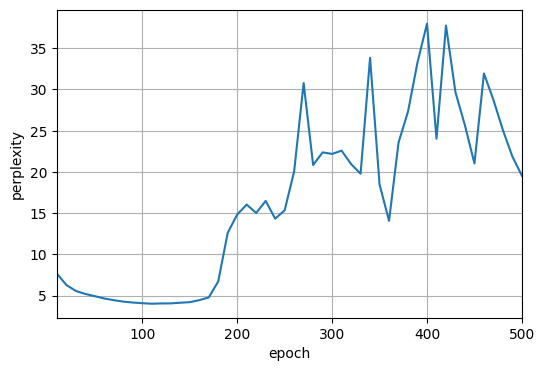

In [15]:
num_epochs, lr = 500, 1
train_ch8(net, train_iter, vocab, lr, num_epochs, device=device)

time traveller and the same the sere the sere the sere the sere 
time traveller stout the stout the stout the stout the stout the
time traveller stind and the story of the story of the story of 
time traveller and strong the stoud of the rean the stoud of the
time traveller stinct the sun strong i me to she was and i could
time traveller s i stood and ston the stars of me and the land a
time traveller seemed to me i saw at my can litted and strong on
time traveller stone the the sands of the same toward made me th
time traveller s could sime the such a blust and it seemed to me
time traveller sition the blows poonless the morlocks the little
time traveller smoked the say i still to the mance of the same t
time traveller smoling on this machine now the stars of the stur
time traveller s ons in the same side of the sun so the sky said
time traveller s mert to my meaning of the sun and but the labor
time traveller still besand and spoke were some of the sky i sto
time traveller and the st

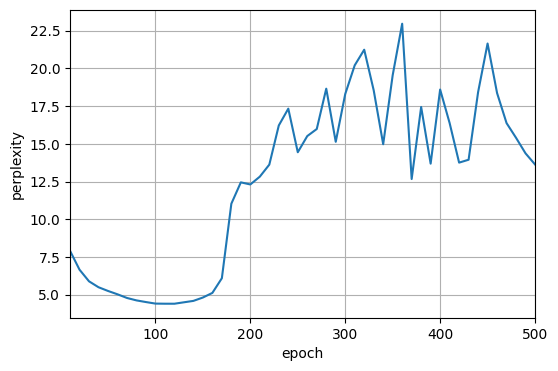

In [18]:
net = RNNModelScratch(
    len(vocab),
    num_hiddens,
    device,
    get_params,
    init_rnn_state,
    rnn
)

train_ch8(net, train_iter, vocab, lr, num_epochs, device=device,
          use_random_iter=True)